In [ ]:
import numpy as np

# I. numpy array cơ bản

1. Tạp array


In [ ]:
a = np.array([1, 2, 3, 4, 5])

In [ ]:
b = np.array([[1,2,3],[4,5,6]])

In [ ]:
zeros =   np.zeros(5)

In [ ]:
ones = np.ones((2, 3))

2. Các hàm tạo array tiện lợi

In [ ]:
r = np.arange(0, 10, 3)
print(r)

[0 3 6 9]


In [ ]:
lin = np.linspace(0, 1,5)
print(lin)

[0.   0.25 0.5  0.75 1.  ]


In [ ]:
nhiet_do = np.array([28.5, 30.1, 29.8, 31.2, 27.6, 26.9, 28.0])
print(nhiet_do)

[28.5 30.1 29.8 31.2 27.6 26.9 28. ]


In [ ]:
diem = np.array([[6,7, 8], [7,8,7], [10, 8, 3]])
print(diem)

[[ 6  7  8]
 [ 7  8  7]
 [10  8  3]]


In [ ]:
e = np.eye(3)
print(e)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


3. Shape — hình dạng của mảng

In [ ]:
arr = np.arange(12)
arr.reshape(3, 4)
print(arr)

[ 0  1  2  3  4  5  6  7  8  9 10 11]


4. Dtype — kiểu dữ liệu

In [ ]:
arr = np.array([[1.0, 2.5, 3.1],
                [4.8, 5.0, 6.2]])
print(arr.nbytes)

48


5. Thuộc tính quan trọng nhất

In [ ]:
arr = np.array([[1.0, 2.5, 3.1],
                [4.8, 5.0, 6.2]])

arr.shape   # → (2, 3)  — 2 hàng, 3 cột
arr.ndim    # → 2      — số chiều
arr.size    # → 6      — tổng số phần tử
arr.dtype   # → float64 — kiểu dữ liệu
arr.nbytes  # → 48     — bộ nhớ (bytes)

48

#II. numpy indexing và slicing

Dataset mẫu — điểm thi của 5 học sinh (4 môn)

In [ ]:
# Hàng = học sinh, Cột = [Toán, Lý, Hóa, Văn]
scores = np.array([
    [85, 72, 90, 78],   # HS 0: An
    [60, 55, 62, 70],   # HS 1: Bình
    [95, 88, 91, 85],   # HS 2: Châu
    [45, 50, 48, 55],   # HS 3: Dũng
    [78, 82, 74, 80],   # HS 4: Em
])

In [ ]:
print(scores)

[[85 72 90 78]
 [60 55 62 70]
 [95 88 91 85]
 [45 50 48 55]
 [78 82 74 80]]


In [ ]:
# Lấy điểm Toán của tất cả học sinh (cột 0)
toan = scores[:, 0]
print(toan)

[85 60 95 45 78]


In [ ]:
# Lấy điểm của HS 2 (Châu) — tất cả môn
chau = scores[2]
print(chau)

[95 88 91 85]


In [ ]:
# Phần tử cuối cùng — index âm
print(scores[-1, -1])

80


In [ ]:
# Slicing tạo VIEW — thay đổi ảnh hưởng array gốc
sub = scores[0:2, :]
sub[0, 0] = 999   # scores bị thay đổi theo
print(scores)

[[999  72  90  78]
 [ 60  55  62  70]
 [ 95  88  91  85]
 [ 45  50  48  55]
 [ 78  82  74  80]]


In [ ]:
# Fancy indexing tạo COPY — an toàn hơn
sub = scores[[0, 1], :]
sub[0, 0] = 999        # scores không bị ảnh hưởng

# III. Broadcasting trong numpy

1. Cộng một số vào mọi phần tử — đây là broadcasting đơn giản nhất. Scalar được "kéo giãn" thành ma trận cùng shape.

In [ ]:
prices = np.array([[10, 20, 30],
                [15, 25, 35]])
tax = 5
result = prices + tax
print(result)

[[15 25 35]
 [20 30 40]]


2. Trừ trung bình từng cột — thao tác chuẩn hóa dữ liệu. Vector (3,) được broadcast theo chiều hàng.

In [ ]:
data = np.array ([[1, 2, 3], [4,5,6], [7,8,9]])
col = [5 ,8 , 7]
temp = data - col
print(temp)

[[-4 -6 -4]
 [-1 -3 -1]
 [ 2  0  2]]


3. Nhân vector cột (3,1) với vector hàng (1,4) — tạo ra bảng tổ hợp (outer product). Cực kỳ hay dùng trong ML.

In [ ]:
rows = np.array([[1],[2],[3]])
col = np.array([10, 20, 30, 40])

print(rows * col)

[[ 10  20  30  40]
 [ 20  40  60  80]
 [ 30  60  90 120]]


4. Khi hai chiều khác nhau và không có chiều nào bằng 1 — NumPy báo lỗi. Không thể kéo giãn.

In [ ]:
# A = np.array([[1, 2, 3],
#                [4, 5, 6]])
# B = np.array([[10, 20],
#                [30, 40]])
# print(A + B)

In [ ]:
A = np.array([[1, 2, 3],
               [4, 5, 6]])
B = np.array([[10, 20, 30],
               [30, 40, 50]]) # Modified B to have shape (2,3) for compatibility
print(A + B)

[[11 22 33]
 [34 45 56]]


#IV. Các hàm toán học trong numpy

In [ ]:
scores = np.array([
    [85, 72, 90, 78],  # An
    [60, 55, 62, 70],  # Bình
    [95, 88, 91, 85],  # Châu
    [45, 50, 48, 55],  # Dũng
    [78, 82, 74, 80],  # Em
])  # shape: (5, 4)

1. Sum (tổng)

In [ ]:
print (np.sum(scores))

1443


2. Mean (trung bình toàn bộ)

In [ ]:
print (np.mean(scores))

72.15


3. std (Độ lệch chuẩn)

In [ ]:
print(np.std(scores))

15.268513352648318


4. Min (Điểm thấp nhất)

In [ ]:
np.min(scores)

np.int64(45)

5. Max (Điểm cao nhất)

In [ ]:
print(np.max(scores))

95


6. Median (Điểm trung bình từng học sinh vs từng môn)

**note**: axis=0 nghĩa là "sụp theo chiều hàng" → kết quả là 1 hàng (thống kê theo cột).
axis=1 nghĩa là "sụp theo chiều cột" → kết quả là 1 cột (thống kê theo hàng)

In [ ]:
# Điểm trung bình từng học sinh
avg_student = np.mean(scores, axis=1)
# Điểm trung bình từng môn
avg_subject = np.mean(scores, axis=0)

In [ ]:
# Chuẩn hóa dữ liệu trước khi đưa vào model
mu  = np.mean(X, axis=0)   # trung bình từng feature
sig = np.std(X, axis=0)    # std từng feature
Z   = (X - mu) / sig       # Z-score, shape giữ nguyên

7. np.linalg — 4 hàm hay dùng nhất trong ML

*  scores @ W hoặc np.dot(): Nhân ma trận — forward pass của neural net
*  np.linalg.norm(v): Tính khoảng cách, chuẩn hóa vector
* np.linalg.eig(C): PCA — tìm chiều dữ liệu quan trọng nhất
* np.corrcoef(X.T): Khám phá tương quan giữa các feature



#V.  Reshape, stack, concatenate, split trong numpy

**1. Reshape — đổi hình, giữ nguyên dữ liệu**

Không sao chép bộ nhớ — chỉ thay đổi cách "đọc" dữ liệu. Tổng số phần tử phải bằng nhau.

In [ ]:
pixels = np.arange(1, 13)          # shape (12,)  ← ảnh flatten
img    = pixels.reshape(3, 4)       # shape (3,4)  ← ảnh 3×4
img_t  = pixels.reshape(4, 3)       # shape (4,3)
flat   = img.reshape(-1)            # shape (12,)  ← -1 tự tính
batch  = pixels.reshape(1, -1)      # shape (1,12) ← thêm batch dim

# Ứng dụng CNN: (samples, H, W) → (samples, H*W)
X = np.random.randn(100, 28, 28)    # 100 ảnh MNIST
X_flat = X.reshape(100, -1)         # (100, 784)

######Tránh bẫy hay gặp:





In [ ]:
import numpy as np

# Define a sample data array and a placeholder process function for demonstration
data = np.array([1, 2, 3, 4, 5])
def process(x):
    return x * 2

# Đừng build array bằng vòng lặp như này
result = np.array([])
for x in data:
    result = np.append(result, process(x))   # chậm kinh khủng! O(n²)
print(f"Result from slow loop: {result}")

# Làm đúng: dùng list, convert một lần cuối
result_fast = [process(x) for x in data]
result_fast = np.array(result_fast)                    # nhanh hơn hàng trăm lần
print(f"Result from fast list comprehension: {result_fast}")

Result from slow loop: [ 2.  4.  6.  8. 10.]
Result from fast list comprehension: [ 2  4  6  8 10]


**2. np.concatenate ghép mảng theo chiều đã có**

In [ ]:
train = np.array([[85,72],[60,55],[95,88]])  # (3,2)
test  = np.array([[78,80],[45,50]])           # (2,2)

# Ghép theo axis=0 (dọc) — thêm hàng
all_data = np.concatenate([train, test], axis=0)
# shape: (5,2)

# Ghép theo axis=1 (ngang) — thêm cột
labels_tr = np.array([[1],[0],[1]])           # (3,1)
train_lbl = np.concatenate([train, labels_tr], axis=1)
# shape: (3,3)

# Shortcut hay dùng
np.vstack([train, test])   # = concatenate axis=0
np.hstack([train, labels_tr]) # = concatenate axis=1

array([[85, 72,  1],
       [60, 55,  0],
       [95, 88,  1]])

In [ ]:
# np.vstack([A, B])      # ghép dọc  — thêm hàng
# np.hstack([A, B])      # ghép ngang — thêm cột
# np.concatenate(...)    # tổng quát, kiểm soát axis
# np.append(A, B)        # tránh dùng! luôn copy toàn bộ mảng

**3. np.stack tạo ra chiều mới**


np.stack tạo ra chiều mới (ndim tăng lên 1). Dùng khi ghép nhiều mẫu thành batch.

In [ ]:
# 3 mẫu điểm thi — mỗi mẫu là vector (4,)
an   = np.array([85, 72, 90, 78])
binh = np.array([60, 55, 62, 70])
chau = np.array([95, 88, 91, 85])

# stack theo axis=0 → thêm chiều batch
batch = np.stack([an, binh, chau], axis=0)
# shape: (3, 4)  ← 3 học sinh, 4 môn

# stack theo axis=1 → ghép theo cột
T = np.stack([an, binh, chau], axis=1)
# shape: (4, 3)  ← 4 môn, 3 học sinh

# Define R, G, B as placeholder arrays (e.g., 2D arrays representing image channels)
R = np.random.rand(100, 100) # Example: 100x100 random values for Red channel
G = np.random.rand(100, 100) # Example: 100x100 random values for Green channel
B = np.random.rand(100, 100) # Example: 100x100 random values for Blue channel

# Ứng dụng ảnh: ghép 3 channel R,G,B → (H,W,3)
rgb = np.stack([R, G, B], axis=-1)

* Stack vs concatenate — điểm khác biệt quan trọng

In [ ]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

print(np.stack([a,b], axis=0))   # (4,) + (4,) → (2,4)  ← chiều MỚI
print(np.concatenate([a,b]))      # (4,) + (4,) → (8,)   ← ghép chiều cũ

[[1 2 3 4]
 [5 6 7 8]]
[1 2 3 4 5 6 7 8]


# VII. Numpy random

**numpy.random** là công cụ không thể thiếu — dùng để tạo dữ liệu test, khởi tạo model, mô phỏng thống kê, và chia train/test.

**1. Seed — tái lập kết quả**

Seed là "chìa khóa" của bộ sinh số ngẫu nhiên. Cùng seed → cùng kết quả. Bắt buộc trong nghiên cứu và debug.

In [ ]:
# Không seed — mỗi lần chạy ra số khác
np.random.randn(3)   # [0.47, -1.23, 0.89] (ví dụ)
np.random.randn(3)   # [-0.12, 2.01, 0.33] (khác!)

# Có seed — luôn ra cùng kết quả
np.random.seed(42)
np.random.randn(3)   # [0.494, -0.138, 0.647]
np.random.seed(42)
np.random.randn(3)   # [0.494, -0.138, 0.647]  ← SAME

# Best practice: dùng Generator mới hơn
rng = np.random.default_rng(seed=42)
rng.standard_normal(3)

array([ 0.30471708, -1.03998411,  0.7504512 ])

Quy tắc vàng

In [ ]:
# Cách cũ (global state — dễ gây bug)
np.random.seed(42)

# Cách mới — dùng Generator riêng biệt
rng = np.random.default_rng(seed=42)  # tạo 1 lần ở đầu script
X = rng.standard_normal((1000, 20))
W = rng.normal(0, 0.01, (20, 10))

**2. Phân phối chuẩn**

Xuất hiện ở khắp nơi: điểm thi, chiều cao, sai số đo lường, khởi tạo weight neural network.



In [ ]:
rng = np.random.default_rng(42)

# Chuẩn hóa (mean=0, std=1)
z = rng.standard_normal(1000)

# Tùy chỉnh mean và std
heights = rng.normal(loc=170, scale=8, size=1000)
# loc=mean, scale=std

# 2D — ma trận ngẫu nhiên
W = rng.normal(0, 0.01, size=(128, 64))  # init weights

# Quy tắc 68-95-99.7
# 68% nằm trong [mean-std, mean+std]
# 95% nằm trong [mean-2std, mean+2std]
# 99.7% nằm trong [mean-3std, mean+3std]

**3. Các phân phối khác**

Mỗi phân phối mô hình hóa một loại hiện tượng khác nhau. Chọn đúng phân phối = mô hình tốt hơn.

In [ ]:
rng = np.random.default_rng(42)

# Uniform — giá trị đều nhau trong [low, high]
prices = rng.uniform(100, 500, 1000)     # giá sản phẩm

# Binomial — n lần thử, xác suất p mỗi lần
clicks = rng.binomial(n=1000, p=0.03, size=500)  # CTR

# Poisson — số sự kiện trong khoảng thời gian
orders = rng.poisson(lam=15, size=365)   # đơn/ngày

# Exponential — thời gian giữa 2 sự kiện
wait   = rng.exponential(scale=5, size=1000)  # phút chờ

# Beta — xác suất, tỉ lệ ∈ [0,1]
conv   = rng.beta(a=2, b=8, size=1000)  # tỉ lệ chuyển đổi

Chọn phân phối theo bài toán

1.   Uniform      → A/B test, random split, noise thêm vào data
2. Binomial     → số lần thành công (click, chuyển đổi, lỗi)
3. Poisson      → số sự kiện/thời gian (đơn hàng, request/giây)
4. Exponential  → thời gian chờ giữa 2 sự kiện
5. Beta         → ước lượng tỉ lệ (CTR, conversion rate)
6. Normal       → sai số, chiều cao, điểm thi, init weights




**4. Shuffle & sampling**

Trộn và lấy mẫu — dùng mỗi khi chia train/test, tạo mini-batch, bootstrap.

In [ ]:
rng = np.random.default_rng(42)
data = np.arange(10)   # [0..9]

# Trộn ngẫu nhiên (in-place)
rng.shuffle(data)
# → [7, 2, 5, 0, 3, 9, 1, 8, 4, 6]

# Chọn k phần tử không lặp (không hoàn lại)
rng.choice(data, size=3, replace=False)
# → [7, 2, 5]

# Chọn có lặp (bootstrap)
rng.choice(data, size=5, replace=True)
# → [7, 7, 2, 9, 2]

# Chia train/test đúng cách
idx = np.arange(len(X))
rng.shuffle(idx)
train_idx = idx[:int(.8*len(idx))]
test_idx  = idx[int(.8*len(idx)):]
X_train, X_test = X[train_idx], X[test_idx]

Lưu ý quan trọng khi shuffle

In [ ]:
# Shuffle X và y phải dùng CÙNG permutation
y = np.arange(len(X)) # Add this line to define y for demonstration
idx = rng.permutation(len(X))
X_shuf, y_shuf = X[idx], y[idx]   # đúng — giữ cặp (X,y)

# ĐỪNG làm thế này — X và y bị lệch nhau!
rng.shuffle(X)
rng.shuffle(y)   # sai!

**5. Giả lập dữ liệu thực tế**

Tạo dataset hoàn chỉnh để test model trước khi có dữ liệu thật — một kỹ năng cực kỳ quan trọng.

In [ ]:
rng = np.random.default_rng(42)
n = 500

# Dataset phân loại: 2 cụm điểm (classification)
X0 = rng.normal([2,2],  1.0, (n//2, 2))  # class 0
X1 = rng.normal([5,5],  1.2, (n//2, 2))  # class 1
X  = np.vstack([X0, X1])
y  = np.array([0]*(n//2) + [1]*(n//2))

# Dataset hồi quy: y = 2x + noise (regression)
x    = rng.uniform(0, 10, 300)
y_r  = 2*x + 1 + rng.normal(0, 2, 300)   # signal + noise

# Dữ liệu bán hàng có mùa vụ (time series)
t      = np.linspace(0, 2*np.pi, 365)
trend  = np.linspace(100, 150, 365)
season = 20 * np.sin(t)
noise  = rng.normal(0, 5, 365)
sales  = trend + season + noise

#VIII. Numpy với pandas và matplotlib

**1 NumPy + Pandas — tạo và nạp dữ liệu**

Dữ liệu thực tế thường bắt đầu từ CSV. NumPy tạo dữ liệu giả lập, Pandas nạp và biểu diễn dạng bảng.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# 1. Tạo dữ liệu giả lập bằng NumPy
n = 200
days    = np.arange(1, n+1)
temp    = rng.normal(28, 3, n).round(1)          # nhiệt độ
promo   = rng.binomial(1, 0.3, n)                # có khuyến mãi?
revenue = (120 + 25*np.sin(days*2*np.pi/60)
           + promo*40
           + rng.normal(0, 15, n)).round(1)

# 2. Tạo DataFrame — cầu nối NumPy → Pandas
df = pd.DataFrame({
    'day':     days,
    'region':  np.tile(['HCM','HN','DN','CT'], n//4),
    'temp':    temp,
    'promo':   promo,
    'revenue': revenue,
})

# 3. Inject NaN để thực hành làm sạch
idx_nan = rng.choice(n, size=8, replace=False)
df.loc[idx_nan, 'revenue'] = np.nan

df.to_csv('sales.csv', index=False)   # lưu
df2 = pd.read_csv('sales.csv')        # nạp lại

Chuyển đổi qua lại NumPy ↔ Pandas

In [ ]:
# df['revenue'].values          # Series  → np.ndarray
# df.values                      # DataFrame → 2D ndarray
# np.array(df['revenue'])        # cách khác
# pd.Series(np_arr, name='col') # ndarray  → Series
# pd.DataFrame(np_2d, columns=['a','b']) # 2D → DataFrame

**2. Làm sạch dữ liệu — numpy + pandas kết hợp**

Phát hiện và xử lý NaN, outlier, kiểu dữ liệu sai — bước tốn nhiều thời gian nhất trong thực tế.

In [ ]:
# 1. Kiểm tra tổng quan
df.info()
df.isnull().sum()         # NaN theo cột
df.describe()             # thống kê cơ bản

# 2. Xử lý NaN — 3 cách phổ biến
df['revenue'].fillna(df['revenue'].median(), inplace=True)
df['temp'].fillna(method='ffill', inplace=True)   # forward fill
df.dropna(inplace=True)                            # xóa hàng

# 3. Phát hiện outlier bằng NumPy (Z-score)
arr = df['revenue'].values          # → ndarray
mu, sigma = arr.mean(), arr.std()
z_scores  = np.abs((arr - mu) / sigma)
outliers  = df[z_scores > 3]        # |z| > 3 là outlier

# 4. Clip outlier thay vì xóa
df['revenue'] = np.clip(arr, mu - 3*sigma, mu + 3*sigma)

# 5. Đúng kiểu dữ liệu
df['promo'] = df['promo'].astype(np.int8)   # tiết kiệm RAM

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   day      200 non-null    int64  
 1   region   200 non-null    object 
 2   temp     200 non-null    float64
 3   promo    200 non-null    int64  
 4   revenue  192 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 7.9+ KB


/tmp/ipykernel_5639/4076353824.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['revenue'].fillna(df['revenue'].median(), inplace=True)
/tmp/ipykernel_5639/4076353824.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Quy tắc chọn cách xử lý NaN

In [ ]:
# fillna(median) #  → số liệu có outlier (doanh thu, giá)
# fillna(mean)   # → phân phối chuẩn, ít outlier
# fillna(ffill)  #  → time series (giá cổ phiếu, sensor)
# dropna()       #  → NaN rất ít (<1%) và không ảnh hưởng

**3. Phân tích với NumPy — tính toán nhanh**

Sau khi có dữ liệu sạch, NumPy làm tất cả phép tính nặng: thống kê, tương quan, chuẩn hóa.

In [ ]:
arr = df['revenue'].values    # DataFrame → ndarray
temp_arr = df['temp'].values
promo_arr = df['promo'].values

# Thống kê mô tả
print(f"mean={arr.mean():.1f}  std={arr.std():.1f}")
print(f"median={np.median(arr):.1f}")
np.percentile(arr, [25, 50, 75])   # IQR

# Phân tích theo nhóm — kết hợp boolean mask
mask_promo = promo_arr == 1
rev_promo   = arr[mask_promo].mean()     # có KM
rev_nopromo = arr[~mask_promo].mean()    # không KM
lift = (rev_promo - rev_nopromo) / rev_nopromo * 100
print(f"Promo lift: +{lift:.1f}%")

# Tương quan NumPy
corr = np.corrcoef(temp_arr, arr)[0,1]
print(f"Tương quan nhiệt độ-doanh thu: {corr:.3f}")

# Chuẩn hóa min-max
arr_norm = (arr - arr.min()) / (arr.max() - arr.min())

mean=133.3  std=29.8
median=136.9
Promo lift: +32.0%
Tương quan nhiệt độ-doanh thu: 0.006


Khi nào dùng NumPy, khi nào dùng Pandas?

In [ ]:
# NumPy               Pandas
# ─────────────────── ───────────────────────
# arr.mean()          df['col'].mean()
# np.corrcoef(a,b)    df.corr()
# np.percentile(a,q)  df.quantile(q)
# arr[mask]           df[df['col']>val]
# np.clip(arr,lo,hi)  df.clip(lo,hi)

**4. Matplotlib — trực quan hóa kết quả**

4 loại biểu đồ dùng nhiều nhất. Matplotlib nhận NumPy array trực tiếp — không cần chuyển đổi.

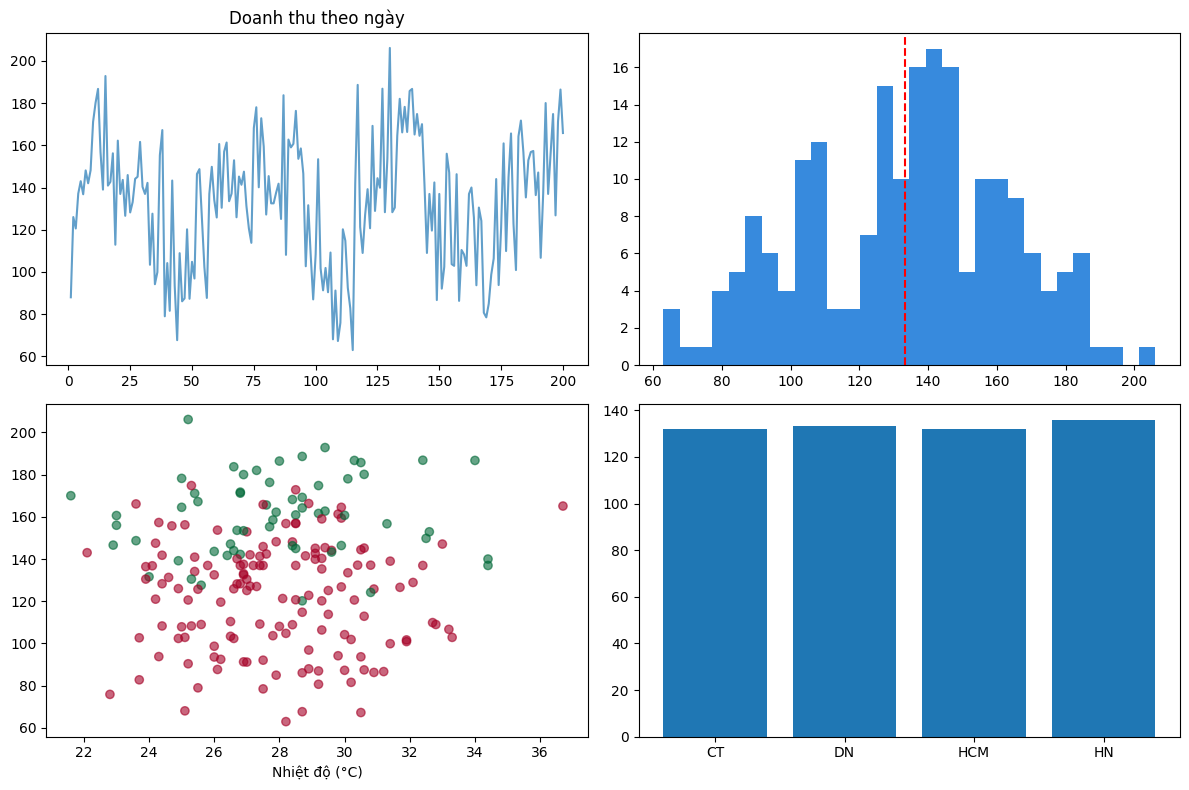

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Line chart — xu hướng theo thời gian
axes[0,0].plot(df['day'], df['revenue'], alpha=0.7)
axes[0,0].set_title('Doanh thu theo ngày')

# 2. Histogram — phân phối
axes[0,1].hist(df['revenue'].values, bins=30, color='#378ADD')
axes[0,1].axvline(df['revenue'].mean(), color='red', ls='--')

# 3. Scatter — tương quan nhiệt độ vs doanh thu
axes[1,0].scatter(df['temp'], df['revenue'],
                  c=df['promo'], cmap='RdYlGn', alpha=0.6)
axes[1,0].set_xlabel('Nhiệt độ (°C)')

# 4. Bar chart — doanh thu trung bình theo vùng
region_mean = df.groupby('region')['revenue'].mean()
axes[1,1].bar(region_mean.index, region_mean.values)

plt.tight_layout()
plt.savefig('analysis.png', dpi=150)

In [ ]:
# Line      → xu hướng thời gian, chuỗi liên tục
# Histogram → phân phối của 1 biến số
# Scatter   → tương quan giữa 2 biến
# Bar       → so sánh giữa các nhóm/danh mục
# Box plot  → phân phối + outlier theo nhóm
# Heatmap   → ma trận tương quan nhiều biến

**5. Pipeline hoàn chỉnh — từ raw data đến insight**

Ghép tất cả lại thành hàm tái sử dụng. Đây là cấu trúc thực tế trong mọi dự án data science.

In [ ]:
def analyse_sales(df):
    """Pipeline hoàn chỉnh: clean → analyse → visualise"""

    # ── 1. Làm sạch ──
    df = df.copy()
    df['revenue'].fillna(df['revenue'].median(), inplace=True)
    arr = df['revenue'].values
    mu, sig = arr.mean(), arr.std()
    df['revenue'] = np.clip(arr, mu-3*sig, mu+3*sig)

    # ── 2. Feature engineering ──
    df['rev_7d_ma'] = df['revenue'].rolling(7).mean()   # MA 7 ngày
    df['rev_norm']  = (arr-arr.min())/(arr.max()-arr.min())
    df['is_high']   = (arr > np.percentile(arr, 75)).astype(int)

    # ── 3. Thống kê theo nhóm ──
    stats = df.groupby('region')['revenue'].agg(
        mean='mean', std='std', count='count'
    ).round(1)

    # ── 4. Insight từ NumPy ──
    promo_lift = (
        arr[df['promo']==1].mean() /
        arr[df['promo']==0].mean() - 1
    ) * 100

    return df, stats, promo_lift

df_clean, region_stats, lift = analyse_sales(df)
print(f"Promo lift: +{lift:.1f}%")
print(region_stats)

Promo lift: +32.0%
         mean   std  count
region                    
CT      132.1  27.5     50
DN      133.1  34.6     50
HCM     132.1  29.3     50
HN      135.8  28.3     50


/tmp/ipykernel_5639/863420757.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['revenue'].fillna(df['revenue'].median(), inplace=True)


#IX. Numpy nâng cao: einsum, memmap, structured arrays, tối ưu hiệu suất

**1. np.einsum — một hàm thay thế hàng chục hàm**

Einstein summation — ký hiệu toán học để diễn đạt bất kỳ phép tính tensor nào. Nhanh, rõ ràng, và dùng trong PyTorch/TensorFlow hàng ngày.

In [ ]:
A = np.random.randn(4, 3)   # (i, k)
B = np.random.randn(3, 5)   # (k, j)

# Nhân ma trận:  sum over k
np.einsum('ik,kj->ij', A, B)   # == A @ B

# Define A_sq for the trace example (A @ A.T results in a square matrix)
A_sq = A @ A.T

# Trace (tổng đường chéo)
np.einsum('ii->', A_sq)         # == np.trace(A_sq)

# Define u and v for the outer product example
u = np.arange(3)
v = np.arange(4)

# Outer product
np.einsum('i,j->ij', u, v)      # == np.outer(u, v)

# Transpose
np.einsum('ij->ji', A)          # == A.T

# Define Q and K for batch matrix multiply
# (batch, seq, d_k) @ (batch, d_k, d_v)
Q = np.random.randn(2, 3, 4) # Example: 2 batches, 3 sequence length, 4-dim features
K = np.random.randn(2, 4, 5) # Example: 2 batches, 4-dim features, 5-dim output

# Batch matrix multiply — phổ biến trong deep learning
np.einsum('bik,bkj->bij', Q, K) # attention score!

# Element-wise rồi sum theo axis
C = np.random.randn(4, 3) # Define C with the same shape as A for element-wise operations
np.einsum('ij,ij->i', A, C)     # row-wise dot product (using A and C)

array([ 0.36598554, -0.32383816,  0.52631873, -0.41337678])

Bảng tra cứu einsum nhanh

In [ ]:
'ij->ji'        # transpose
'ii->'          # trace
'i,i->'         # dot product (vectors)
'ij,jk->ik'     # matmul
'i,j->ij'       # outer product
'ij,ij->i'      # row-wise dot
'bij,bjk->bik'  # batch matmul
'bihd,bjhd->bij'# multi-head attention scores

'bihd,bjhd->bij'

**2. Views vs Copies — hiểu bộ nhớ để tránh bug>>Views vs Copies — hiểu bộ nhớ để tránh buViews vs Copies — hiểu bộ nhớ để tránh bug**

View chia sẻ bộ nhớ với mảng gốc — nhanh, tiết kiệm RAM nhưng dễ gây side effect. Copy tạo bản mới — an toàn nhưng tốn RAM.

In [ ]:
A = np.arange(12).reshape(3, 4)

# ── TẠO VIEW (chia sẻ bộ nhớ) ──
B = A[0:2, :]         # slicing → VIEW
C = A.reshape(2, 6)   # reshape → VIEW
D = A.T               # transpose → VIEW
E = A[::2]            # stride → VIEW

B[0, 0] = 999         # ← A bị thay đổi theo!

# Kiểm tra: .base không None → là view
print(B.base is A)    # True
print(C.flags['OWNDATA'])  # False → view

# ── TẠO COPY (bộ nhớ độc lập) ──
F = A.copy()          # explicit copy
G = A[[0,2], :]       # fancy indexing → COPY
H = A[A > 5]          # boolean mask → COPY

F[0, 0] = 999         # A không bị ảnh hưởng

# ── KIỂM TRA nhanh ──
np.shares_memory(A, B)   # True  → view
np.shares_memory(A, F)   # False → copy

False
False


False

**3. Dtype & tối ưu RAM — tiết kiệm 4–8x bộ nhớ**

Mặc định NumPy dùng float64 (8 bytes). Trong ML, float32 thường đủ — tiết kiệm RAM gấp đôi, tốc độ GPU tăng gấp đôi.

In [ ]:
# Mặc định: float64 — 8 bytes/phần tử
A = np.ones((1000, 1000))          # 8 MB

# Đổi sang float32 — đủ cho hầu hết ML
A32 = A.astype(np.float32)        # 4 MB  ← giảm 50%
A16 = A.astype(np.float16)        # 2 MB  ← giảm 75%

# Số nguyên — tiết kiệm hơn nữa
labels = np.array([0,1,2], dtype=np.int8)   # 1 byte
counts = np.array([100],   dtype=np.int32)  # 4 bytes

# Structured array — bảng không dùng Pandas
dtype = np.dtype([
    ('name',    'U10'),    # Unicode 10 ký tự
    ('age',     np.int8),  # 1 byte
    ('score',   np.float32),# 4 bytes
    ('passed',  np.bool_),  # 1 byte
])
students = np.zeros(100, dtype=dtype)
students['name'][0]  = 'An'
students['score'][0] = 85.5

# Lọc như Pandas
passed = students[students['passed']==True]

Structured array — khi nào nên dùng thay Pandas?


Dùng structured array khi:
  * Dataset cực lớn, mỗi byte quan trọng
  * Không cần groupby, merge, pivot
  * Cần tốc độ truy cập C-level
  * Làm việc với binary file (sensor, image header)

Dùng Pandas khi:
  * Cần groupby, merge, resample
  * Data analysis tương tác (Jupyter)
  * Mixed operations trên nhiều cột


**4. Vectorization — xóa sổ vòng lặp Python**

Vòng lặp Python chậm hơn NumPy vectorized ~100x. Đây là kỹ năng quan trọng nhất để viết code data science nhanh.

In [ ]:
# ── XẤU: Python for loop ──
def normalize_loop(X):
    result = np.zeros_like(X)
    for i in range(X.shape[0]):         # chậm!
        for j in range(X.shape[1]):
            mu = X[:, j].mean()
            s  = X[:, j].std()
            result[i, j] = (X[i, j] - mu) / s
    return result

# ── TỐT: Vectorized ──
def normalize_vec(X):
    mu = X.mean(axis=0)    # shape (d,) — broadcast
    s  = X.std(axis=0)     # shape (d,)
    return (X - mu) / s    # (n,d) - (d,) = broadcast

# ── TỐT: np.vectorize — wrapper tự động ──
def process_one(x, threshold):
    return np.log1p(x) if x > threshold else 0.0

process_all = np.vectorize(process_one)
result = process_all(arr, threshold=5.0)

# ── TUYỆT VỜI: where thay if/else ──
result = np.where(arr > 5, np.log1p(arr), 0.0)

# ── Stacking tricks ──
# Khoảng cách Euclidean: n điểm vs m điểm → (n,m)
diff = X[:, np.newaxis, :] - Y[np.newaxis, :, :]
dists = np.sqrt((diff**2).sum(axis=-1))

Checklist vectorize

In [ ]:
# for i in range(n):          → axis=0 operation
# for i,j in ...:             → 2D broadcast
# if x > threshold: ... else  → np.where(cond, a, b)
# result.append(f(x))         → np.vectorize(f)(arr)
# np.append trong loop        → list rồi np.array() cuối

**5. np.memmap — xử lý file lớn hơn RAM**

Memory-mapped file: đọc một phần dữ liệu từ disk vào RAM theo yêu cầu. Xử lý dataset GB/TB mà không cần load hết.

In [ ]:
fp = np.memmap('big_data.npy',
               dtype='float32',
               mode='w+',        # write+
               shape=(1_000_000, 256))  # 1M × 256 float32 = 1GB

# Ghi từng chunk — không load hết vào RAM
CHUNK = 10_000
for i in range(0, 1_000_000, CHUNK):
    fp[i:i+CHUNK] = process(raw_data[i:i+CHUNK])
fp.flush()   # ghi ra disk

# Đọc chỉ phần cần dùng
mm = np.memmap('big_data.npy', dtype='float32',
               mode='r', shape=(1_000_000, 256))
batch = mm[0:CHUNK]      # chỉ 10000 hàng vào RAM
mean_feature = mm[:, 0].mean()  # 1 cột — lazy read

# Ứng dụng: train model theo chunk
n_samples = mm.shape[0]
for epoch in range(1):
    print(f"Epoch {epoch + 1}/")
    for i in range(0, n_samples, CHUNK):
        X_batch = mm[i:i+CHUNK]    # từng batch từ disk
        # Generate dummy binary target labels for the batch
        # Assuming a binary classification problem for SGDClassifier
        y_batch = np.random.randint(0, 2, size=X_batch.shape[0])
        model.partial_fit(X_batch, y_batch, classes=np.array([0, 1]))
print("Training loop executed successfully.")


Epoch 1/
Training loop executed successfully.


Khi nào dùng memmap?

In [ ]:
# Dataset > RAM/4         → memmap + chunk processing
# Nhiều process cùng đọc  → memmap (OS cache tự nhiên)
# Append liên tục         → memmap mode='r+'
# Training neural net     → HDF5 (h5py) hoặc memmap
# Dataset < RAM           → np.load() bình thường

#mini project

In [ ]:
# ── Bước 1: Tạo dữ liệu & EDA ─────────────────
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N   = 365

# Sinh doanh thu 3 cửa hàng (triệu VNĐ/ngày)
trend   = 100 + np.arange(N) * 0.12
season  = 20  * np.sin(np.arange(N) * 2*np.pi / 90)
weekend = (np.arange(N) % 7 >= 5).astype(float) * 18
noise   = rng.normal(0, 14, N)
revenue = trend + season + weekend + noise

# Thống kê nhanh
print(f"shape: {revenue.shape}")
print(f"mean={revenue.mean():.1f}  std={revenue.std():.1f}")
print(f"min={revenue.min():.1f}   max={revenue.max():.1f}")
np.percentile(revenue, [25, 50, 75])

shape: (365,)
mean=126.9  std=23.6
min=66.3   max=195.5


array([109.62444331, 126.79774748, 144.3632604 ])

In [ ]:
# ── Bước 2: Phát hiện & xử lý dữ liệu bẩn ─────
# Inject NaN (mô phỏng sensor lỗi)
nan_idx = rng.choice(N, 12, replace=False)
revenue[nan_idx] = np.nan

# Kiểm tra
n_nan = np.isnan(revenue).sum()        # → 12

# Điền NaN bằng median (robust với outlier)
median = np.nanmedian(revenue)
revenue = np.where(np.isnan(revenue), median, revenue)

# Phát hiện outlier bằng Z-score
z = (revenue - revenue.mean()) / revenue.std()
outliers = np.where(np.abs(z) > 2.5)[0]   # → 8 ngày

# Clip thay vì xóa (giữ nguyên số hàng)
lo, hi = np.percentile(revenue, [1, 99])
revenue = np.clip(revenue, lo, hi)

In [ ]:
# ── Bước 3: Feature Engineering ─────────────────
# 1. Rolling mean — làm mịn nhiễu
ma7  = np.convolve(revenue, np.ones(7)/7,  mode='same')
ma30 = np.convolve(revenue, np.ones(30)/30, mode='same')

# 2. Lag feature — revenue ngày hôm qua
lag1 = np.roll(revenue, 1)
lag1[0] = revenue[0]

# 3. Chuẩn hóa Min-Max về [0, 1]
rev_norm = (revenue - revenue.min()) / (revenue.max() - revenue.min())

# 4. Z-score normalization
rev_z = (revenue - revenue.mean()) / revenue.std()

# 5. Boolean features
is_weekend = (np.arange(N) % 7 >= 5).astype(np.int8)
is_promo   = (np.arange(N) % 30 < 3).astype(np.int8)

# 6. Tương quan với revenue
np.corrcoef(is_weekend, revenue)[0,1]  # → +0.43
np.corrcoef(is_promo,   revenue)[0,1]  # → +0.31

np.float64(-0.020886302211409167)

In [ ]:
# ── Bước 4: Phân tích chuyên sâu ────────────────
# Doanh thu theo tháng
# Create an array to map each day to a month (0-11)
month_indices = np.floor(np.arange(N) / (N / 12)).astype(int)

monthly = [revenue[month_indices==m].mean() for m in range(12)]
monthly = np.array(monthly)
growth  = np.diff(monthly) / monthly[:-1] * 100

# So sánh ngày thường vs cuối tuần
wkd_mean = revenue[~is_weekend.astype(bool)].mean()
wke_mean = revenue[is_weekend.astype(bool)].mean()
print(f"Weekend lift: +{(wke_mean/wkd_mean-1)*100:.1f}%")

# Hiệu quả khuyến mãi
promo_mean    = revenue[is_promo.astype(bool)].mean()
nonpromo_mean = revenue[~is_promo.astype(bool)].mean()
lift = (promo_mean - nonpromo_mean) / nonpromo_mean * 100
print(f"Promo lift: +{lift:.1f}%")

# Ma trận tương quan
X = np.stack([revenue, is_weekend, is_promo, lag1], axis=1)
np.corrcoef(X.T)

Weekend lift: +14.9%
Promo lift: +-1.2%


array([[ 1.        ,  0.35539295, -0.0208863 ,  0.59825769],
       [ 0.35539295,  1.        , -0.02185486,  0.02874836],
       [-0.0208863 , -0.02185486,  1.        , -0.01596571],
       [ 0.59825769,  0.02874836, -0.01596571,  1.        ]])

In [ ]:
# ── Bước 5: Linear Regression thuần NumPy ───────
# Ordinary Least Squares: y = a + b*x
x = np.arange(N, dtype=float)
x_mean, y_mean = x.mean(), revenue.mean()

b = np.sum((x - x_mean) * (revenue - y_mean)) /     np.sum((x - x_mean)**2)
a = y_mean - b * x_mean

print(f"Trend: y = {a:.2f} + {b:.4f}·day")
print(f"Tăng trưởng: +{b*30:.2f} tr/tháng")

predicted  = a + b * x
residuals  = revenue - predicted
ss_res = np.sum(residuals**2)
ss_tot = np.sum((revenue - y_mean)**2)
R2 = 1 - ss_res / ss_tot
print(f"R² = {R2:.3f}")

# Dự báo 30 ngày tới
future_x   = np.arange(N, N+30)
forecast   = a + b * future_x
conf_band  = residuals.std() * 1.96   # 95% CI

Trend: y = 109.31 + 0.0982·day
Tăng trưởng: +2.95 tr/tháng
R² = 0.202


In [ ]:
monthNames = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
total_rev  = revenue.sum()
best_month = monthNames[np.argmax(monthly)]
worst_month= monthNames[np.argmin(monthly)]
# best_store = max(store_stats, key=lambda s: s['total'])

print(f"Tổng doanh thu 2024: {total_rev/1000:.0f} tỷ VNĐ")
print(f"Tháng tốt nhất: {best_month}")
# print(f"Cửa hàng số 1: {best_store['name']}")
print(f"Tăng trưởng trend: +{b*365:.1f} tr/năm")
print(f"Weekend premium: +{(wke_mean/wkd_mean-1)*100:.1f}%")
print(f"Promo ROI: +{lift:.1f}% doanh thu")

# Prepare growth for np.column_stack, ensuring same length as monthly
growth_padded = np.insert(growth, 0, np.nan)

# Xuất kết quả
np.save('cleaned_revenue.npy', revenue)
np.savetxt('monthly_stats.csv',
    np.column_stack([monthly, growth_padded]),
    delimiter=',', header='mean,growth_pct')

Tổng doanh thu 2024: 46 tỷ VNĐ
Tháng tốt nhất: Oct
Tăng trưởng trend: +35.9 tr/năm
Weekend premium: +14.9%
Promo ROI: +-1.2% doanh thu
